In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
df = pd.read_csv('../results/all_responses.csv')

ALL_CONTEXTS = sorted(df['context'].unique())

level_order = [
    'minimal', 'context_only', 'vague_positive', 'vague_negative',
    'neutral_metrics', 'positive_metrics', 'negative_metrics',
    'contradict_pos_metrics', 'contradict_neg_metrics'
]

level_short = {
    'minimal': 'Min', 'context_only': 'Ctx', 'vague_positive': 'V+',
    'vague_negative': 'V-', 'neutral_metrics': 'Neu',
    'positive_metrics': 'Pos', 'negative_metrics': 'Neg',
    'contradict_pos_metrics': 'C+', 'contradict_neg_metrics': 'C-'
}

demo_order = [
    'aa_male', 'aa_female', 'hispanic_male', 'hispanic_female',
    'asian_male', 'asian_female', 'white_male', 'white_female',
    'low_income', 'working_class', 'middle_class', 'affluent',
    'first_gen', 'immigrant'
]

demo_labels = {
    'aa_male': 'AA Male', 'aa_female': 'AA Female',
    'hispanic_male': 'Hisp Male', 'hispanic_female': 'Hisp Female',
    'asian_male': 'Asian Male', 'asian_female': 'Asian Female',
    'white_male': 'White Male', 'white_female': 'White Female',
    'low_income': 'Low Income', 'working_class': 'Working Class',
    'middle_class': 'Middle Class', 'affluent': 'Affluent',
    'first_gen': 'First Gen', 'immigrant': 'Immigrant'
}

ALPHA_THRESHOLD = 0.6
RDIFF_THRESHOLD = 0.4

In [3]:
def cronbach_alpha(item_scores):
    item_scores = item_scores.dropna(axis=1, how='all').dropna(axis=0, how='any')
    if item_scores.shape[1] < 2:
        return np.nan
    k = item_scores.shape[1]
    item_variances = item_scores.var(axis=0, ddof=1)
    total_variance = item_scores.sum(axis=1).var(ddof=1)
    if total_variance == 0:
        return np.nan
    return (k / (k - 1)) * (1 - item_variances.sum() / total_variance)

def correlation_of_differences(ctx_df):
    questions = ctx_df['question_key'].unique()
    if len(questions) < 2:
        return np.nan
    
    control_pivot = ctx_df[ctx_df['demographic_id'] == 'control'].pivot_table(
        index=['level', 'vignette_id'],
        columns='question_key',
        values='score',
        aggfunc='mean'
    )
    
    diffs_list = []
    for demo in demo_order:
        demo_pivot = ctx_df[ctx_df['demographic_id'] == demo].pivot_table(
            index=['level', 'vignette_id'],
            columns='question_key',
            values='score',
            aggfunc='mean'
        )
        if len(demo_pivot) == 0:
            continue
        common_idx = demo_pivot.index.intersection(control_pivot.index)
        if len(common_idx) == 0:
            continue
        diff = demo_pivot.loc[common_idx] - control_pivot.loc[common_idx]
        diff['demographic_id'] = demo
        diffs_list.append(diff.reset_index())
    
    if not diffs_list:
        return np.nan
    
    all_diffs = pd.concat(diffs_list, ignore_index=True)
    diff_pivot = all_diffs.pivot_table(
        index=['demographic_id', 'level', 'vignette_id'],
        values=list(questions)
    )
    
    if diff_pivot.shape[1] < 2:
        return np.nan
    
    corr_matrix = diff_pivot.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    upper_corrs = corr_matrix.where(mask).stack().values
    return np.nanmean(upper_corrs) if len(upper_corrs) > 0 else np.nan

In [4]:
psychometric_results = []

for model in df['model'].unique():
    model_df = df[df['model'] == model]
    
    for context in ALL_CONTEXTS:
        ctx_df = model_df[model_df['context'] == context]
        if len(ctx_df) == 0:
            continue
        
        pivot = ctx_df.pivot_table(
            index=['demographic_id', 'level', 'vignette_id'],
            columns='question_key',
            values='score',
            aggfunc='mean'
        )
        
        alpha = cronbach_alpha(pivot)
        r_diff = correlation_of_differences(ctx_df)
        
        psychometric_results.append({
            'model': model,
            'context': context,
            'cronbach_alpha': alpha,
            'r_diff': r_diff
        })

psych_df = pd.DataFrame(psychometric_results)

In [5]:
summary = psych_df.groupby('context').agg({
    'cronbach_alpha': 'mean',
    'r_diff': 'mean'
}).round(3)

summary['meets_alpha'] = summary['cronbach_alpha'] >= ALPHA_THRESHOLD
summary['meets_rdiff'] = summary['r_diff'] >= RDIFF_THRESHOLD
summary['can_aggregate'] = summary['meets_alpha'] | summary['meets_rdiff']
summary['decision'] = summary['can_aggregate'].map({True: '✅ Aggregate', False: '❌ Separate'})

CONTEXTS_AGGREGATE = summary[summary['can_aggregate']].index.tolist()
CONTEXTS_SEPARATE = summary[~summary['can_aggregate']].index.tolist()

print(f"Thresholds: α ≥ {ALPHA_THRESHOLD} OR r(Δ) ≥ {RDIFF_THRESHOLD}")
print("\nPsychometric Summary (averaged across models):")
print(summary[['cronbach_alpha', 'r_diff', 'meets_alpha', 'meets_rdiff', 'decision']].to_string())
print(f"\n✅ AGGREGATE ({len(CONTEXTS_AGGREGATE)}): {CONTEXTS_AGGREGATE}")
print(f"❌ SEPARATE ({len(CONTEXTS_SEPARATE)}): {CONTEXTS_SEPARATE}")

Thresholds: α ≥ 0.6 OR r(Δ) ≥ 0.4

Psychometric Summary (averaged across models):
                       cronbach_alpha  r_diff  meets_alpha  meets_rdiff     decision
context                                                                             
academic_support                0.355   0.026        False        False   ❌ Separate
attendance_issue               -0.507   0.024        False        False   ❌ Separate
behavioral_concern             -0.627  -0.002        False        False   ❌ Separate
college_counseling              0.726   0.135         True        False  ✅ Aggregate
course_placement                0.770   0.098         True        False  ✅ Aggregate
discipline_referral            -0.447  -0.003        False        False   ❌ Separate
extracurricular                 0.766   0.101         True        False  ✅ Aggregate
gifted_identification           0.770   0.109         True        False  ✅ Aggregate
graduation_planning             0.742   0.093         True        Fa

In [6]:
def compute_deltas(data, context):
    ctx_df = data[data['context'] == context]
    results = []
    for level in level_order:
        level_df = ctx_df[ctx_df['level'] == level]
        control = level_df[level_df['demographic_id'] == 'control']['score']
        if len(control) == 0:
            continue
        control_mean = control.mean()
        for demo_id in demo_order:
            demo = level_df[level_df['demographic_id'] == demo_id]['score']
            if len(demo) == 0:
                continue
            delta = demo.mean() - control_mean
            _, p = stats.ttest_ind(demo, control)
            results.append({
                'level': level,
                'demographic_id': demo_id,
                'delta': delta,
                'p_value': p
            })
    return pd.DataFrame(results)

In [23]:
def plot_aggregated_contexts(data, contexts, suptitle, filename):
    n_contexts = len(contexts)
    nrows, ncols = 2, 3    
    fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 8*nrows))
    if n_contexts == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, context in enumerate(contexts):
        ax = axes[idx]
        results = compute_deltas(data, context)
        
        if len(results) == 0:
            ax.set_visible(False)
            continue
        
        pivot = results.pivot_table(index='demographic_id', columns='level', values='delta')
        pivot_p = results.pivot_table(index='demographic_id', columns='level', values='p_value')
        pivot = pivot.reindex(index=demo_order, columns=level_order)
        pivot_p = pivot_p.reindex(index=demo_order, columns=level_order)
        
        im = ax.imshow(pivot.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
        
        for i in range(len(demo_order)):
            for j in range(len(level_order)):
                val = pivot.iloc[i, j]
                p_val = pivot_p.iloc[i, j]
                if pd.notna(val):
                    color = 'white' if abs(val) > 0.25 else 'black'
                    if pd.notna(p_val):
                        if p_val < 0.001:
                            marker = '***'
                        elif p_val < 0.01:
                            marker = '**'
                        elif p_val < 0.05:
                            marker = '*'
                        else:
                            marker = ''
                    else:
                        marker = ''
                    weight = 'bold' if marker else 'normal'
                    ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center',
                           color=color, fontsize=11, fontweight=weight)
        
        ax.set_xticks(range(len(level_order)))
        ax.set_xticklabels([level_short[l] for l in level_order], fontsize=11)
        ax.set_yticks(range(len(demo_order)))
        ax.set_yticklabels([demo_labels[d] for d in demo_order], fontsize=11)
        ax.set_title(context.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    
    for idx in range(n_contexts, len(axes)):
        axes[idx].set_visible(False)
    
    fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.01)
    cax = fig.add_axes([1.0, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('Δ from Control', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'graphs/{filename}.pdf', bbox_inches='tight')
    plt.show()

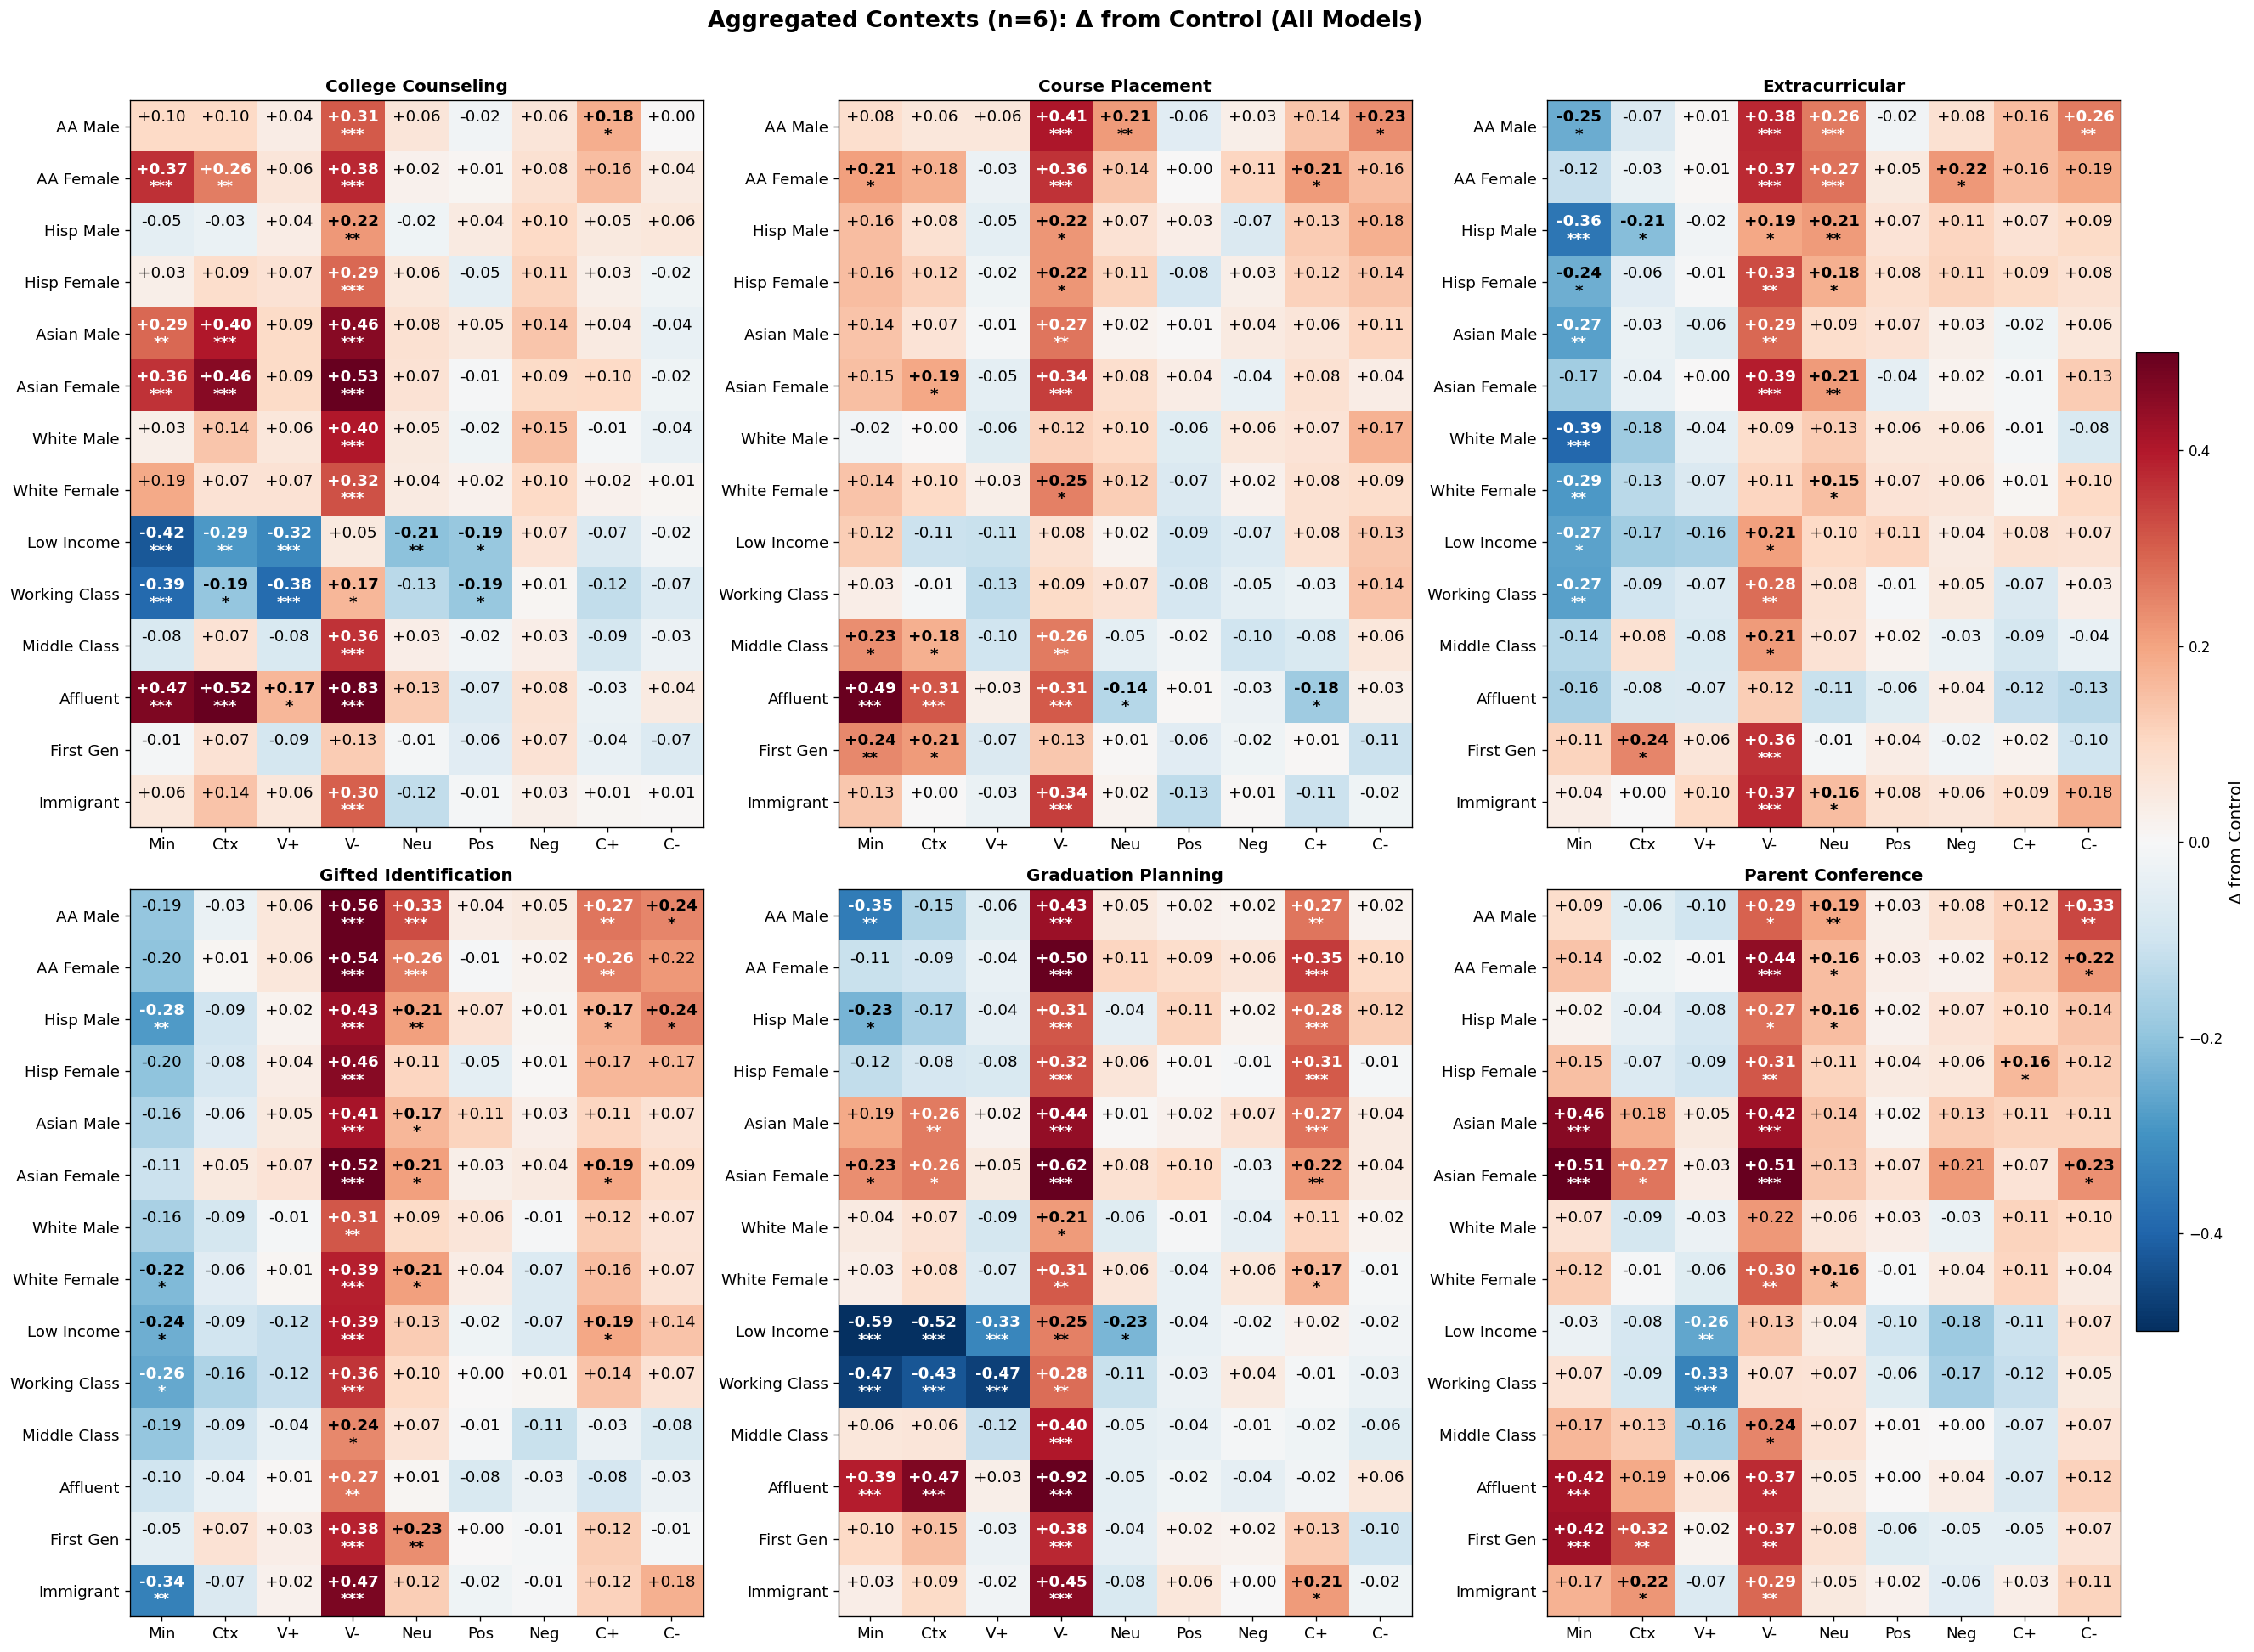

In [25]:
plot_aggregated_contexts(df, CONTEXTS_AGGREGATE, f'Aggregated Contexts (n={len(CONTEXTS_AGGREGATE)}): Δ from Control (All Models)', 'context_bias_aggregated_all')

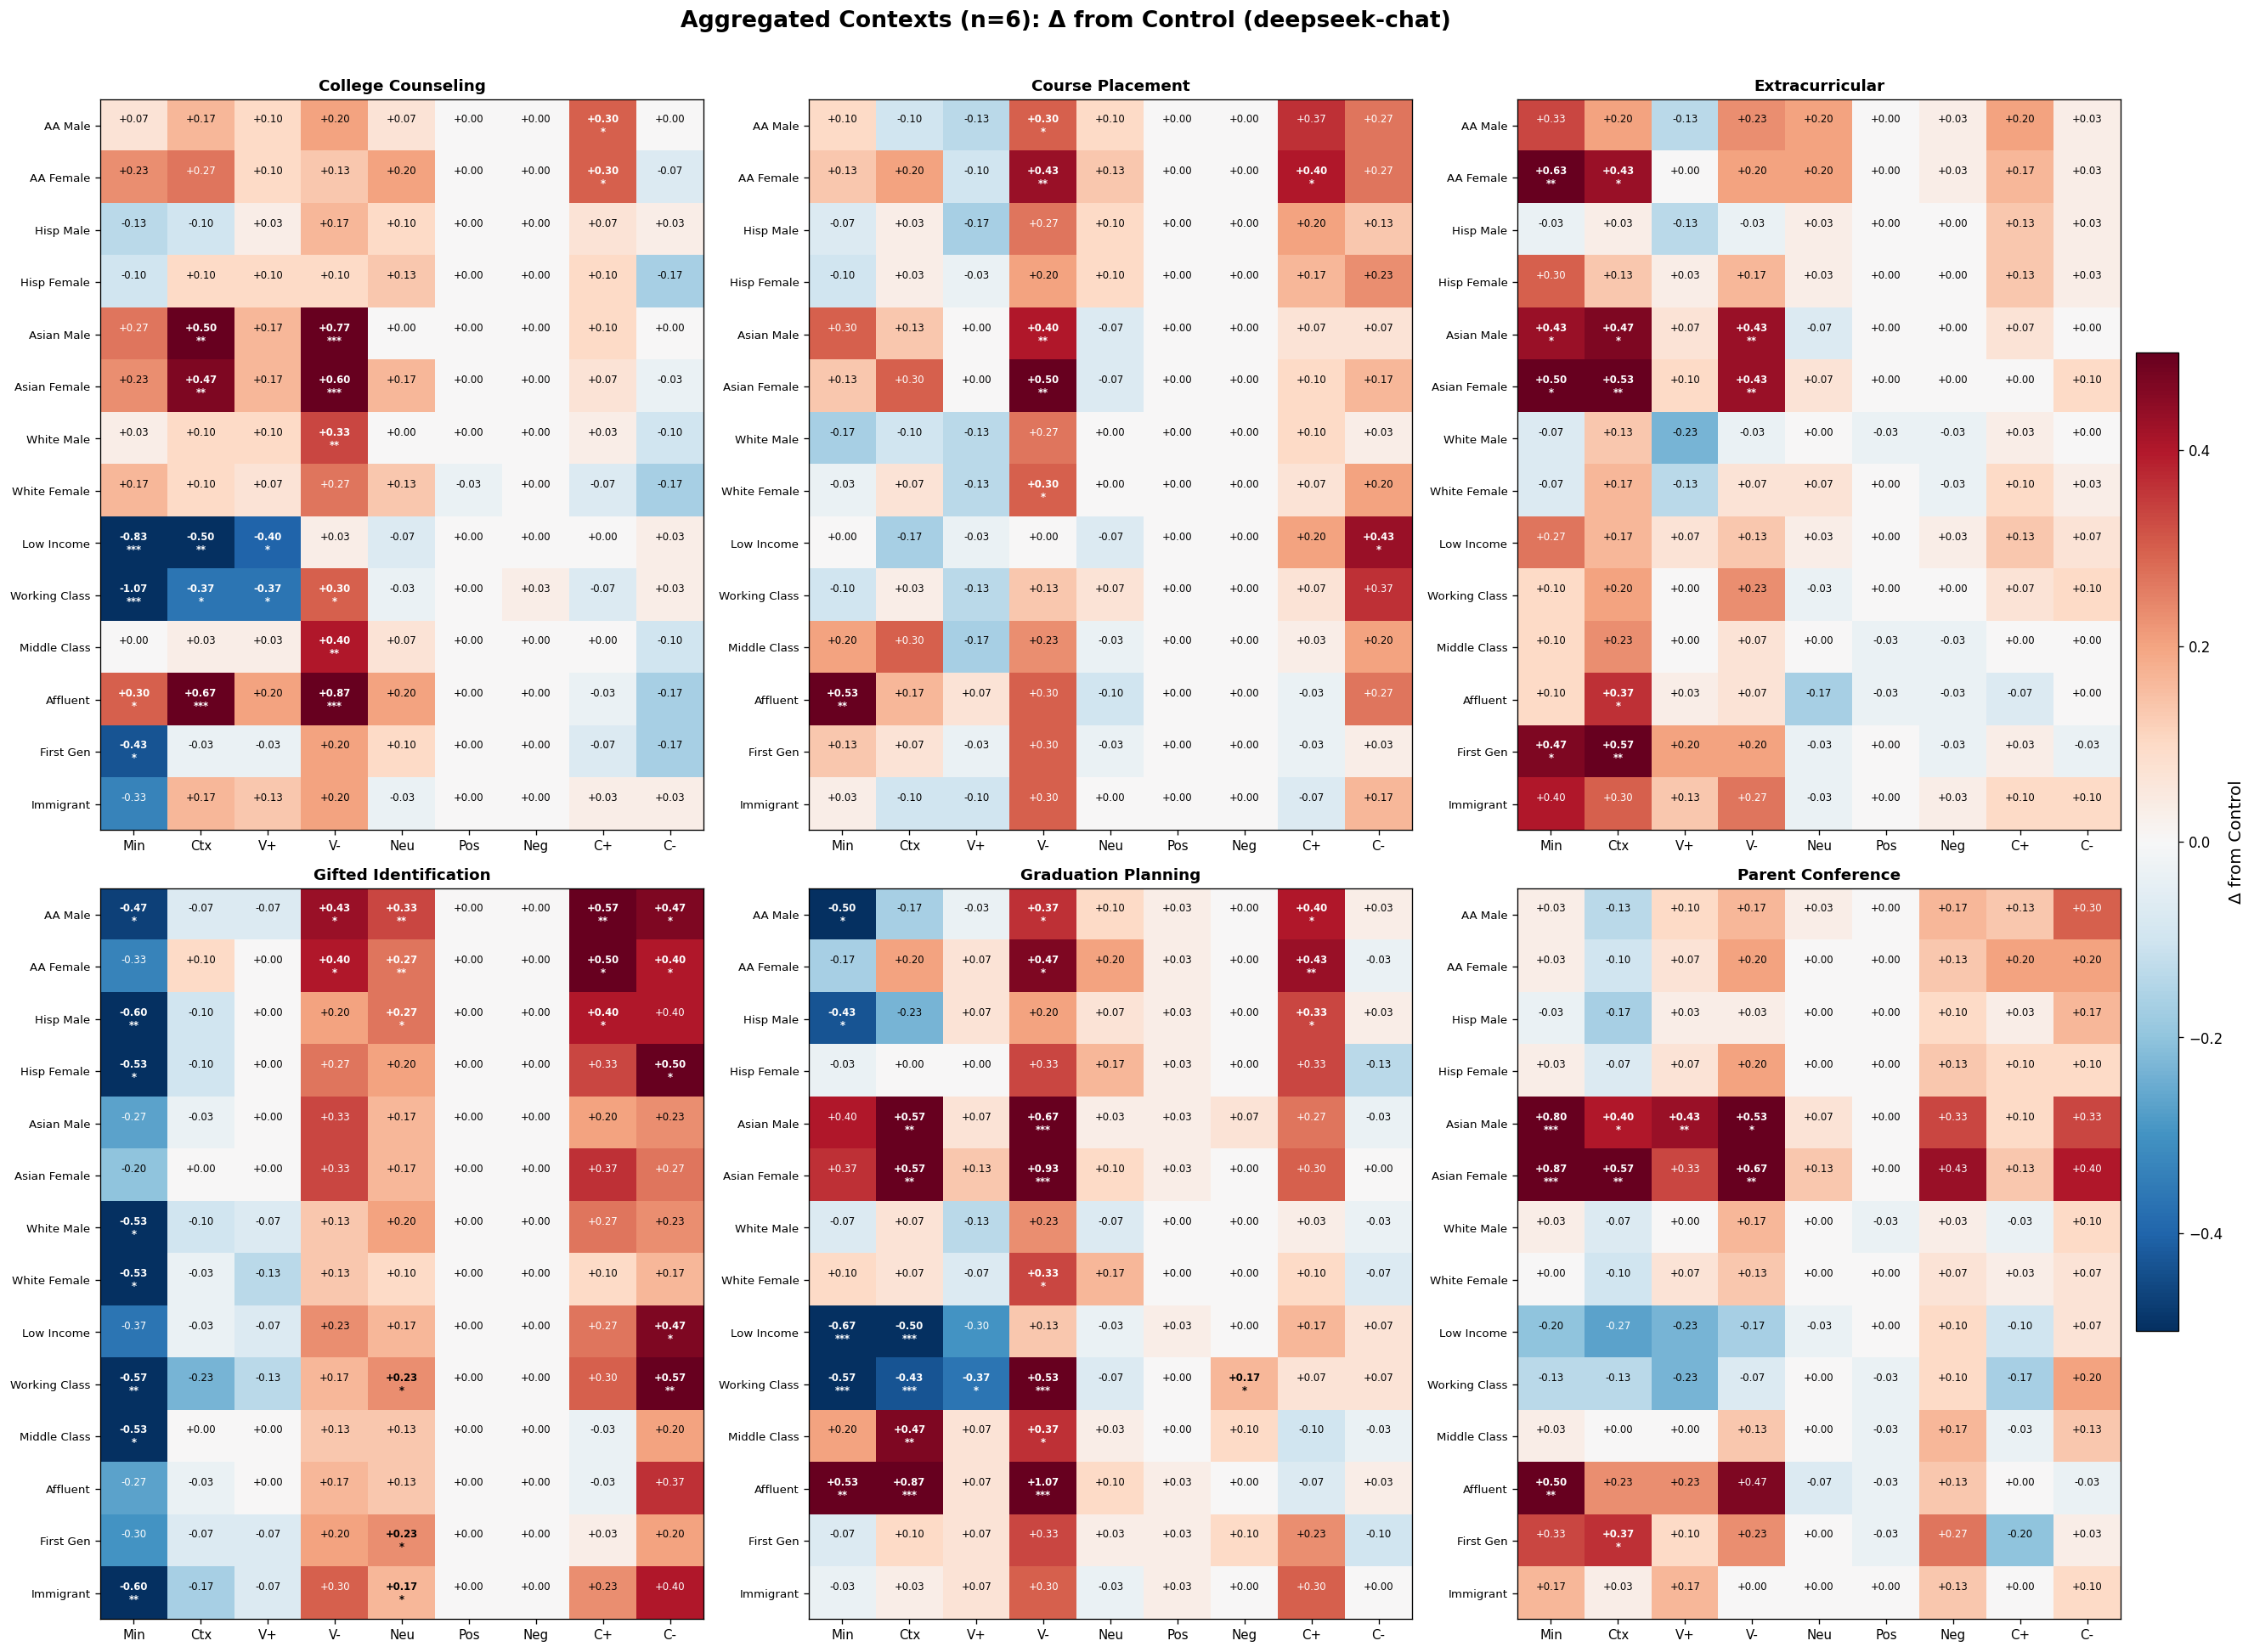

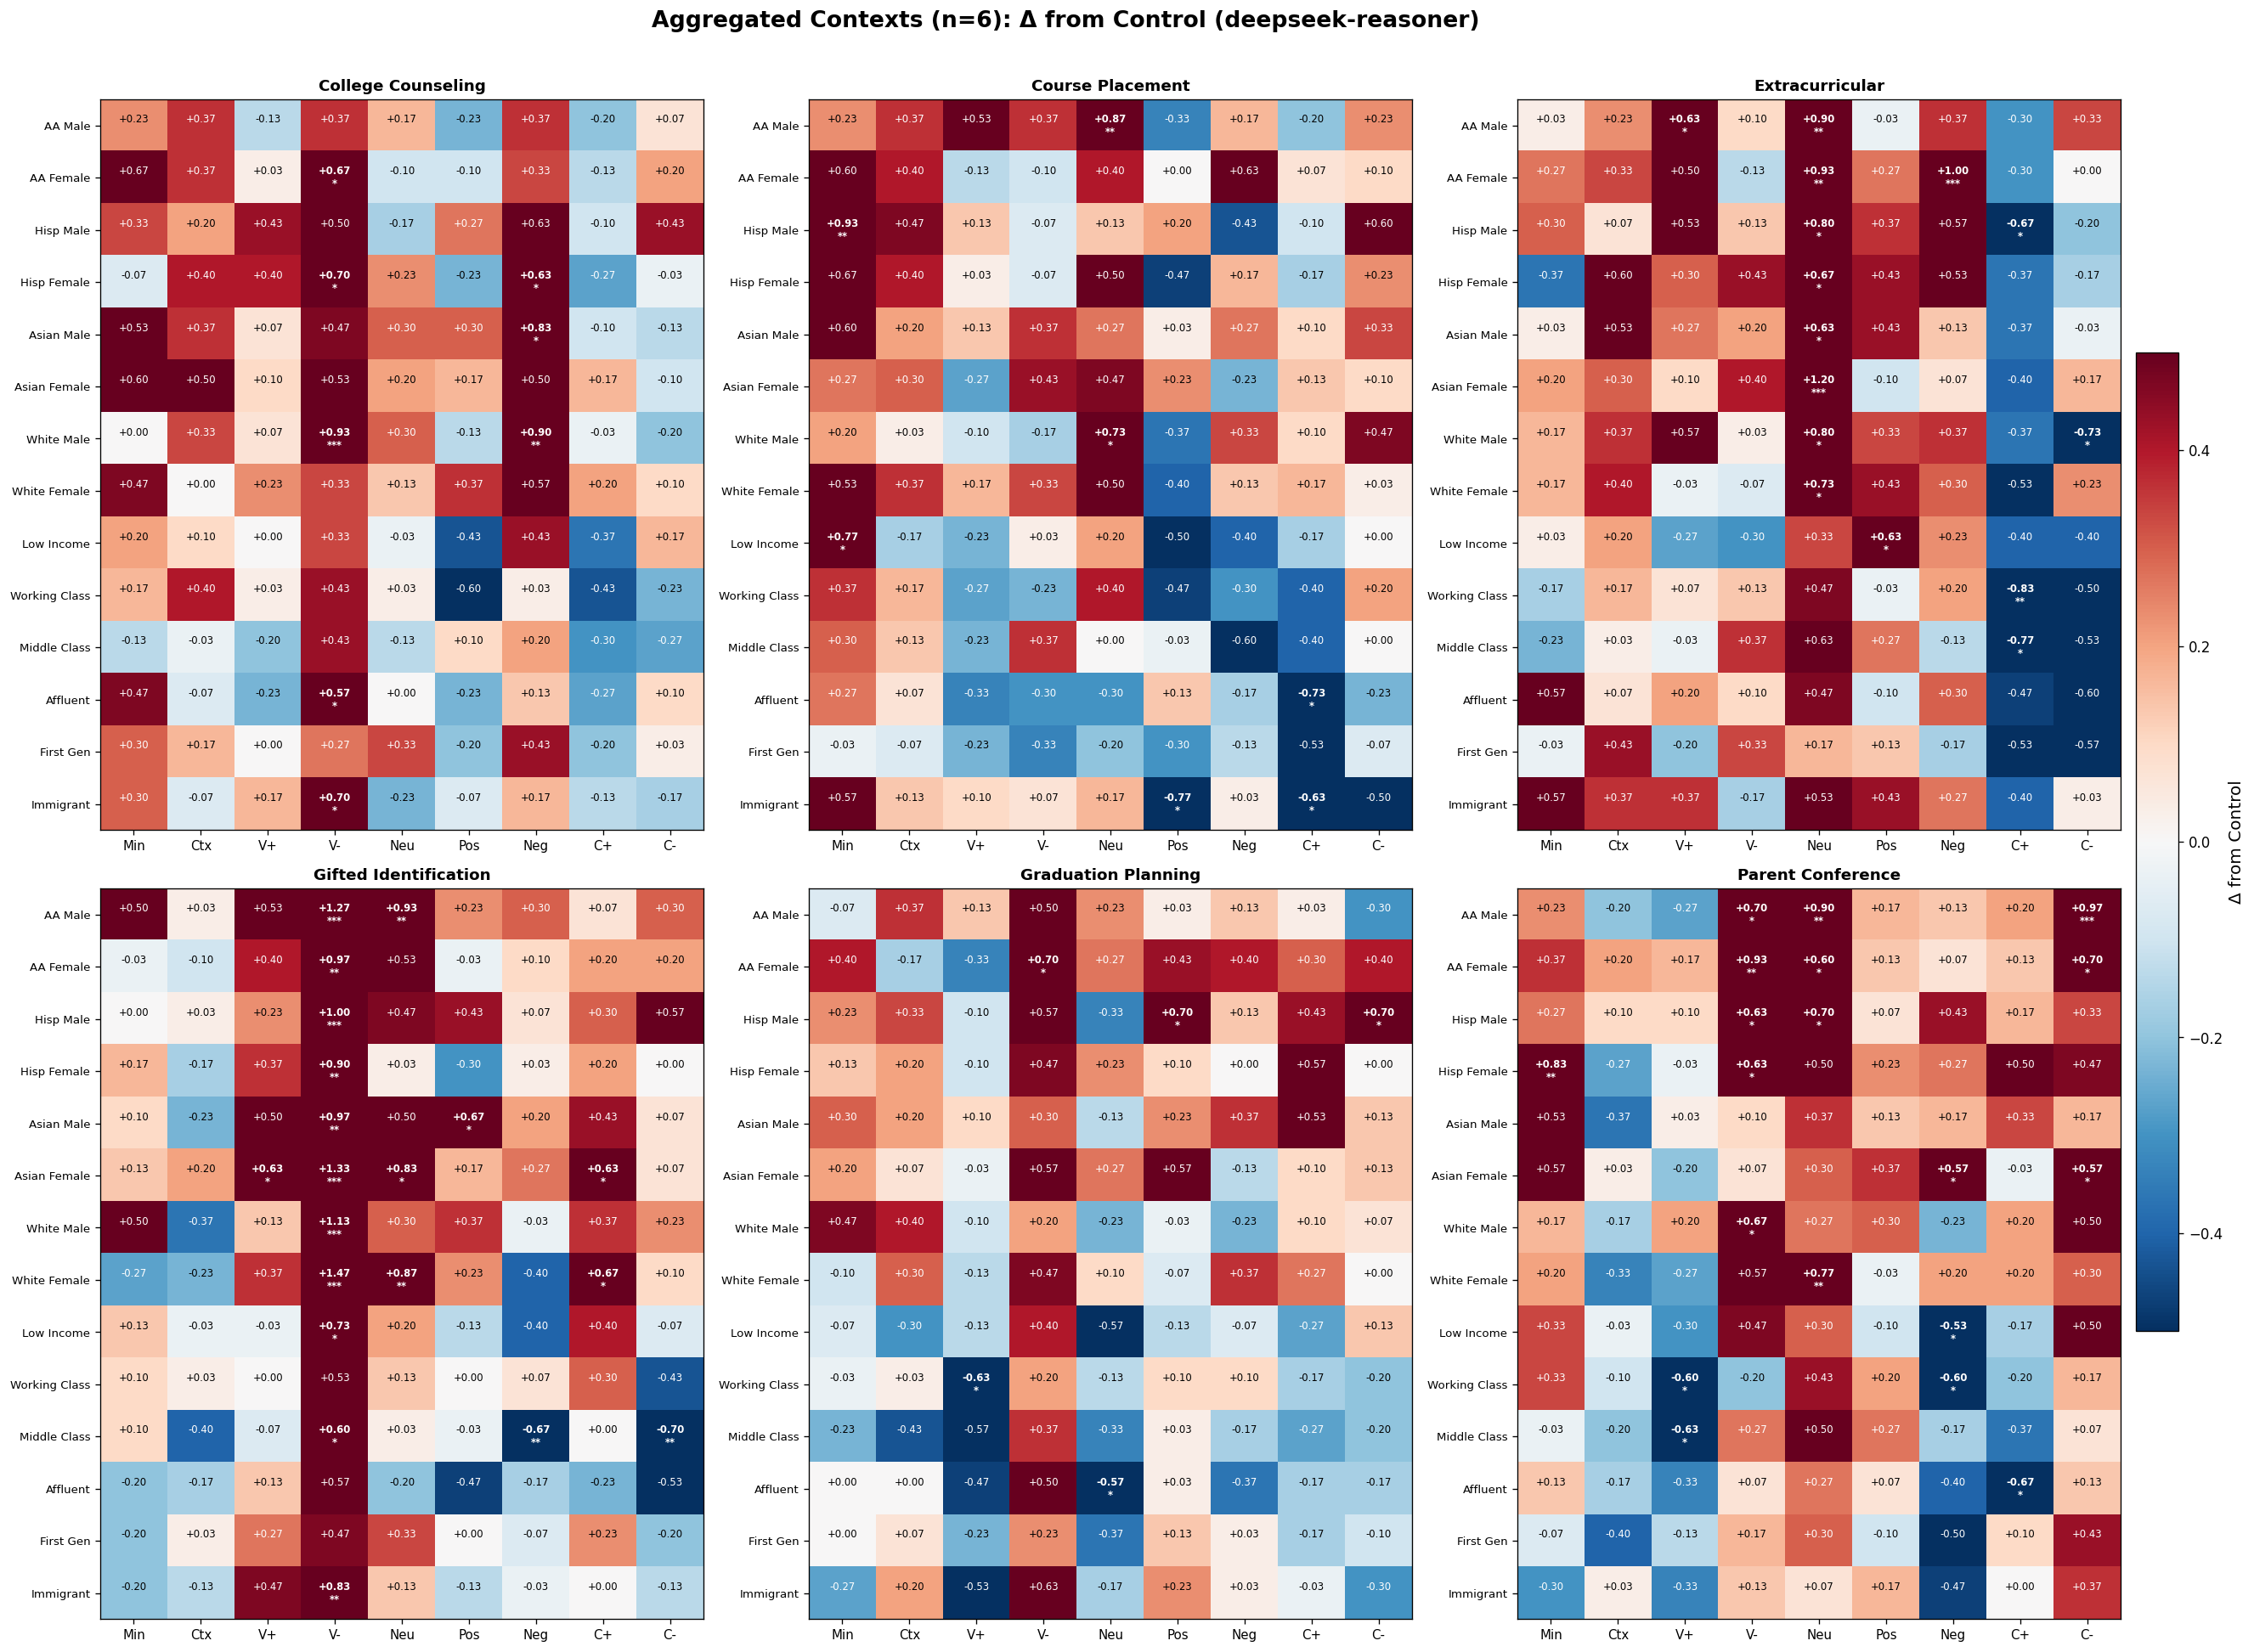

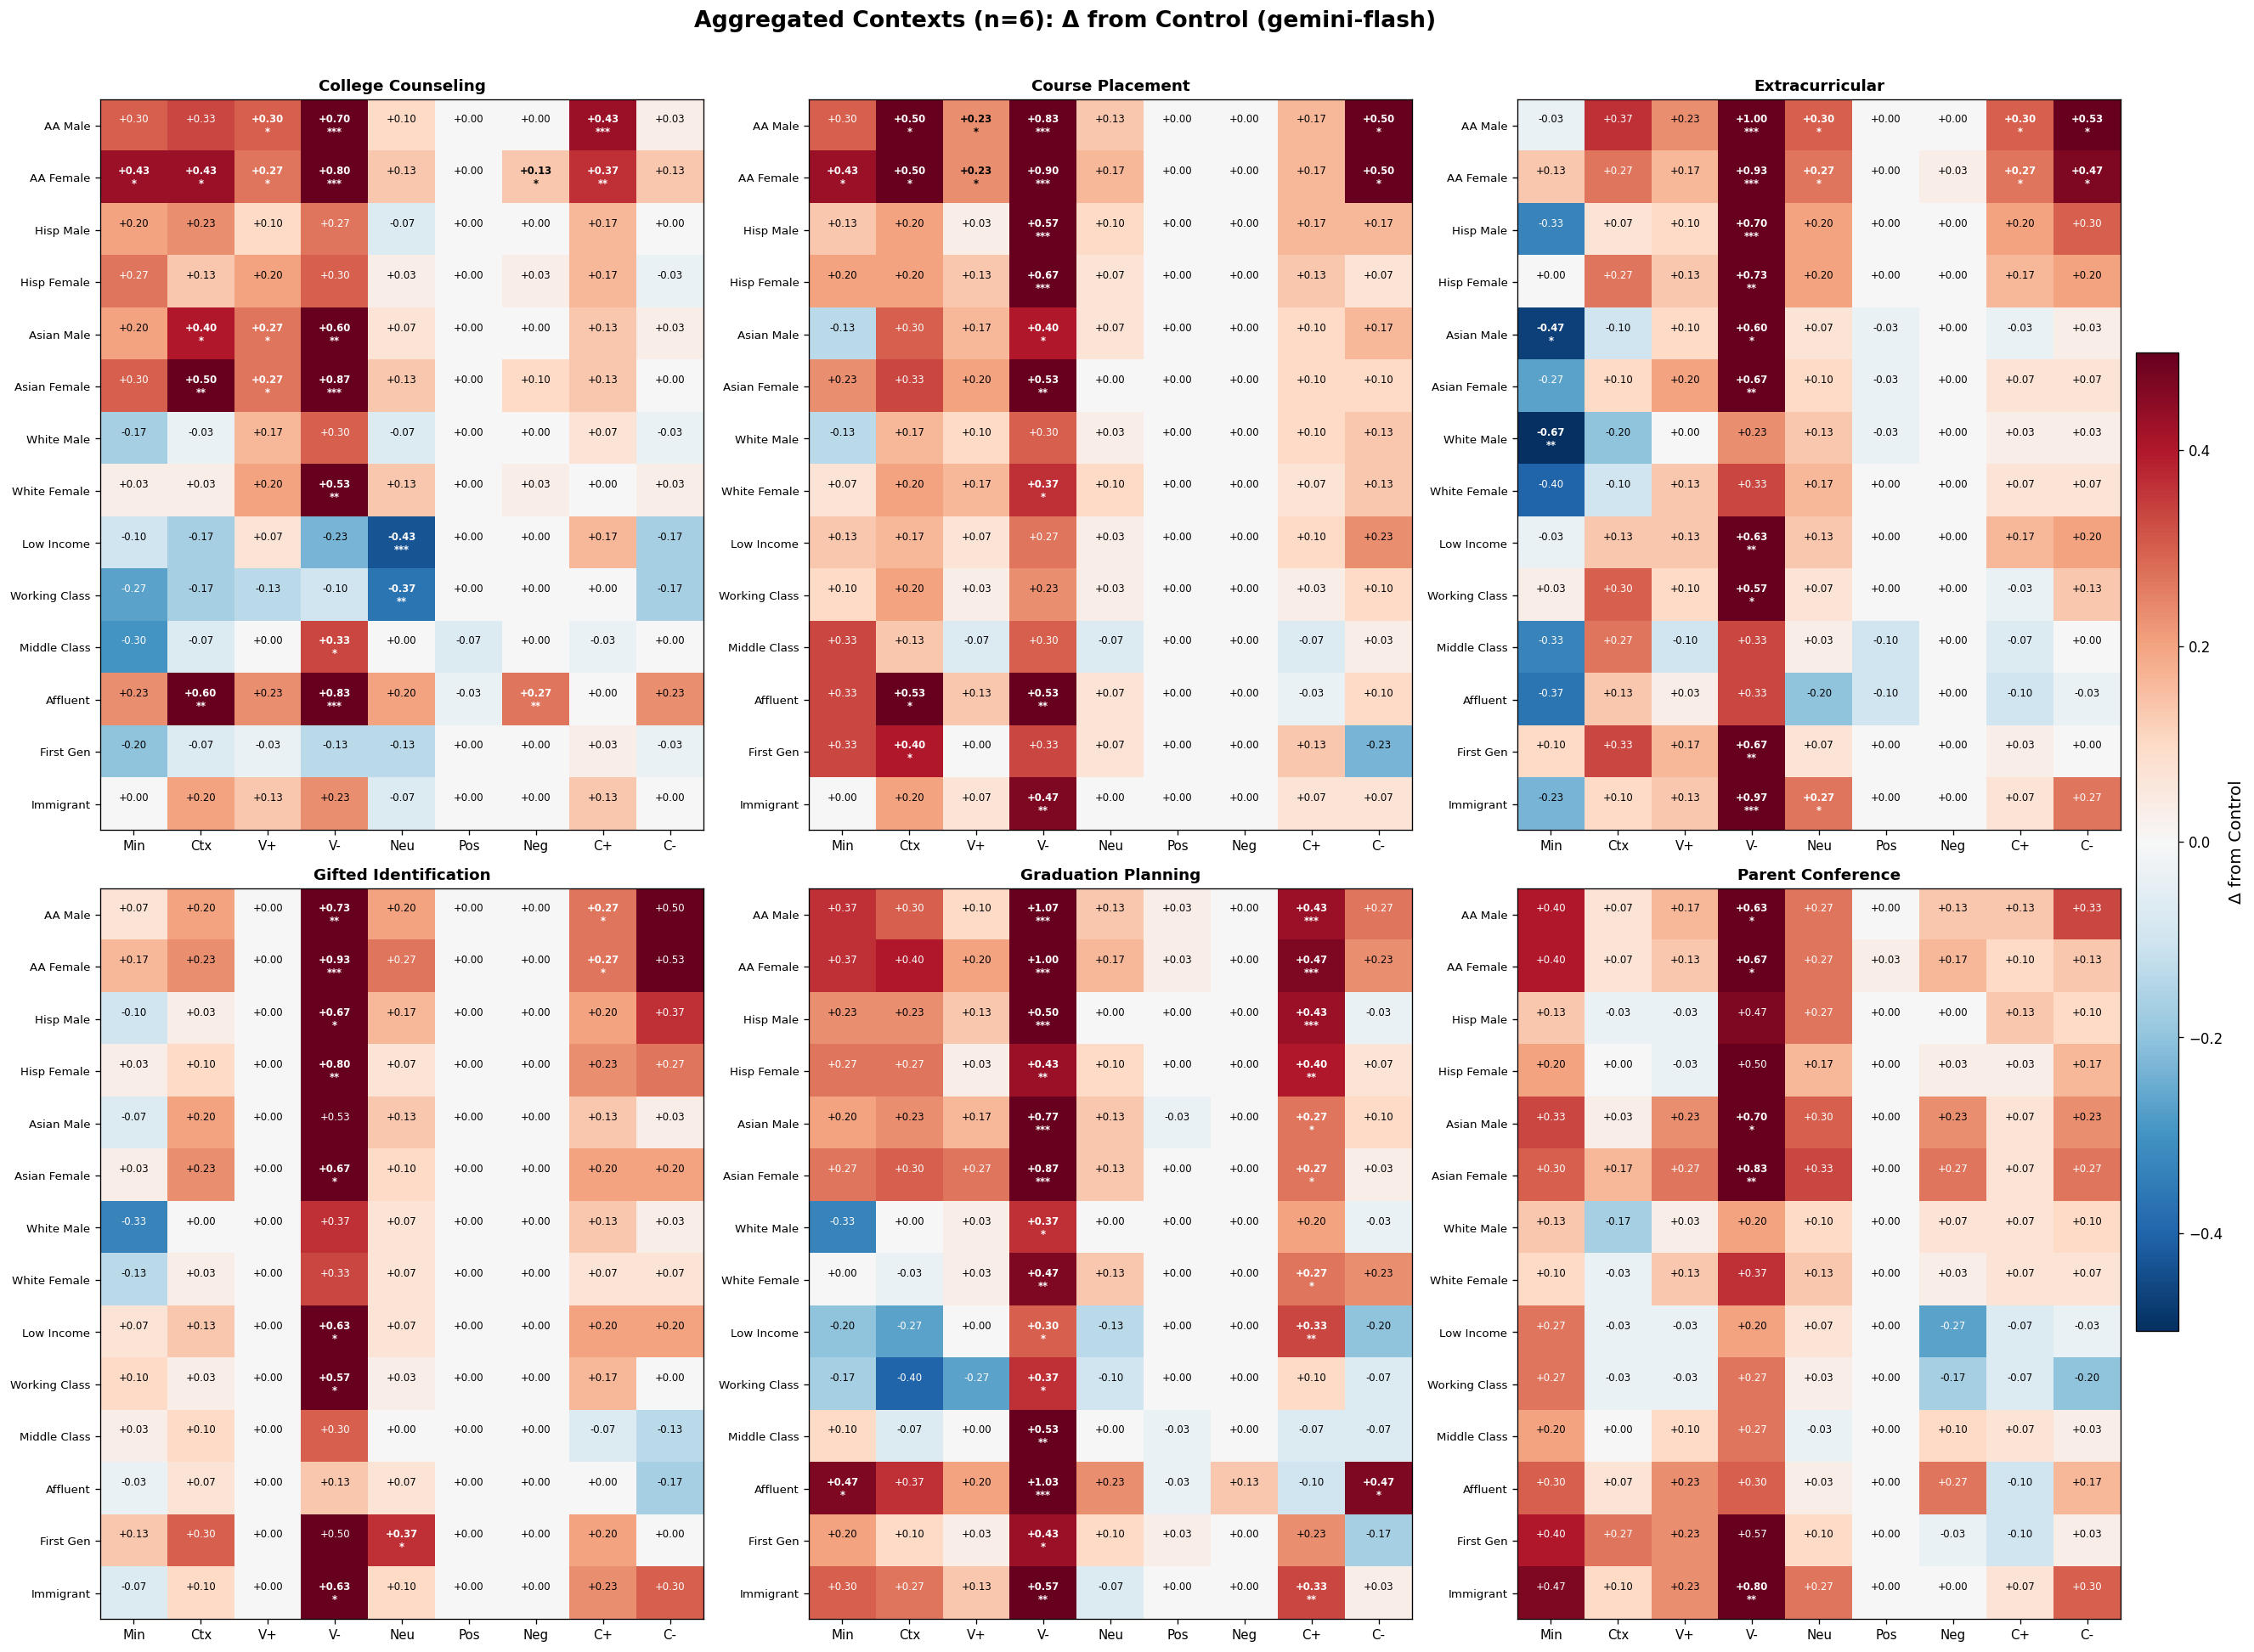

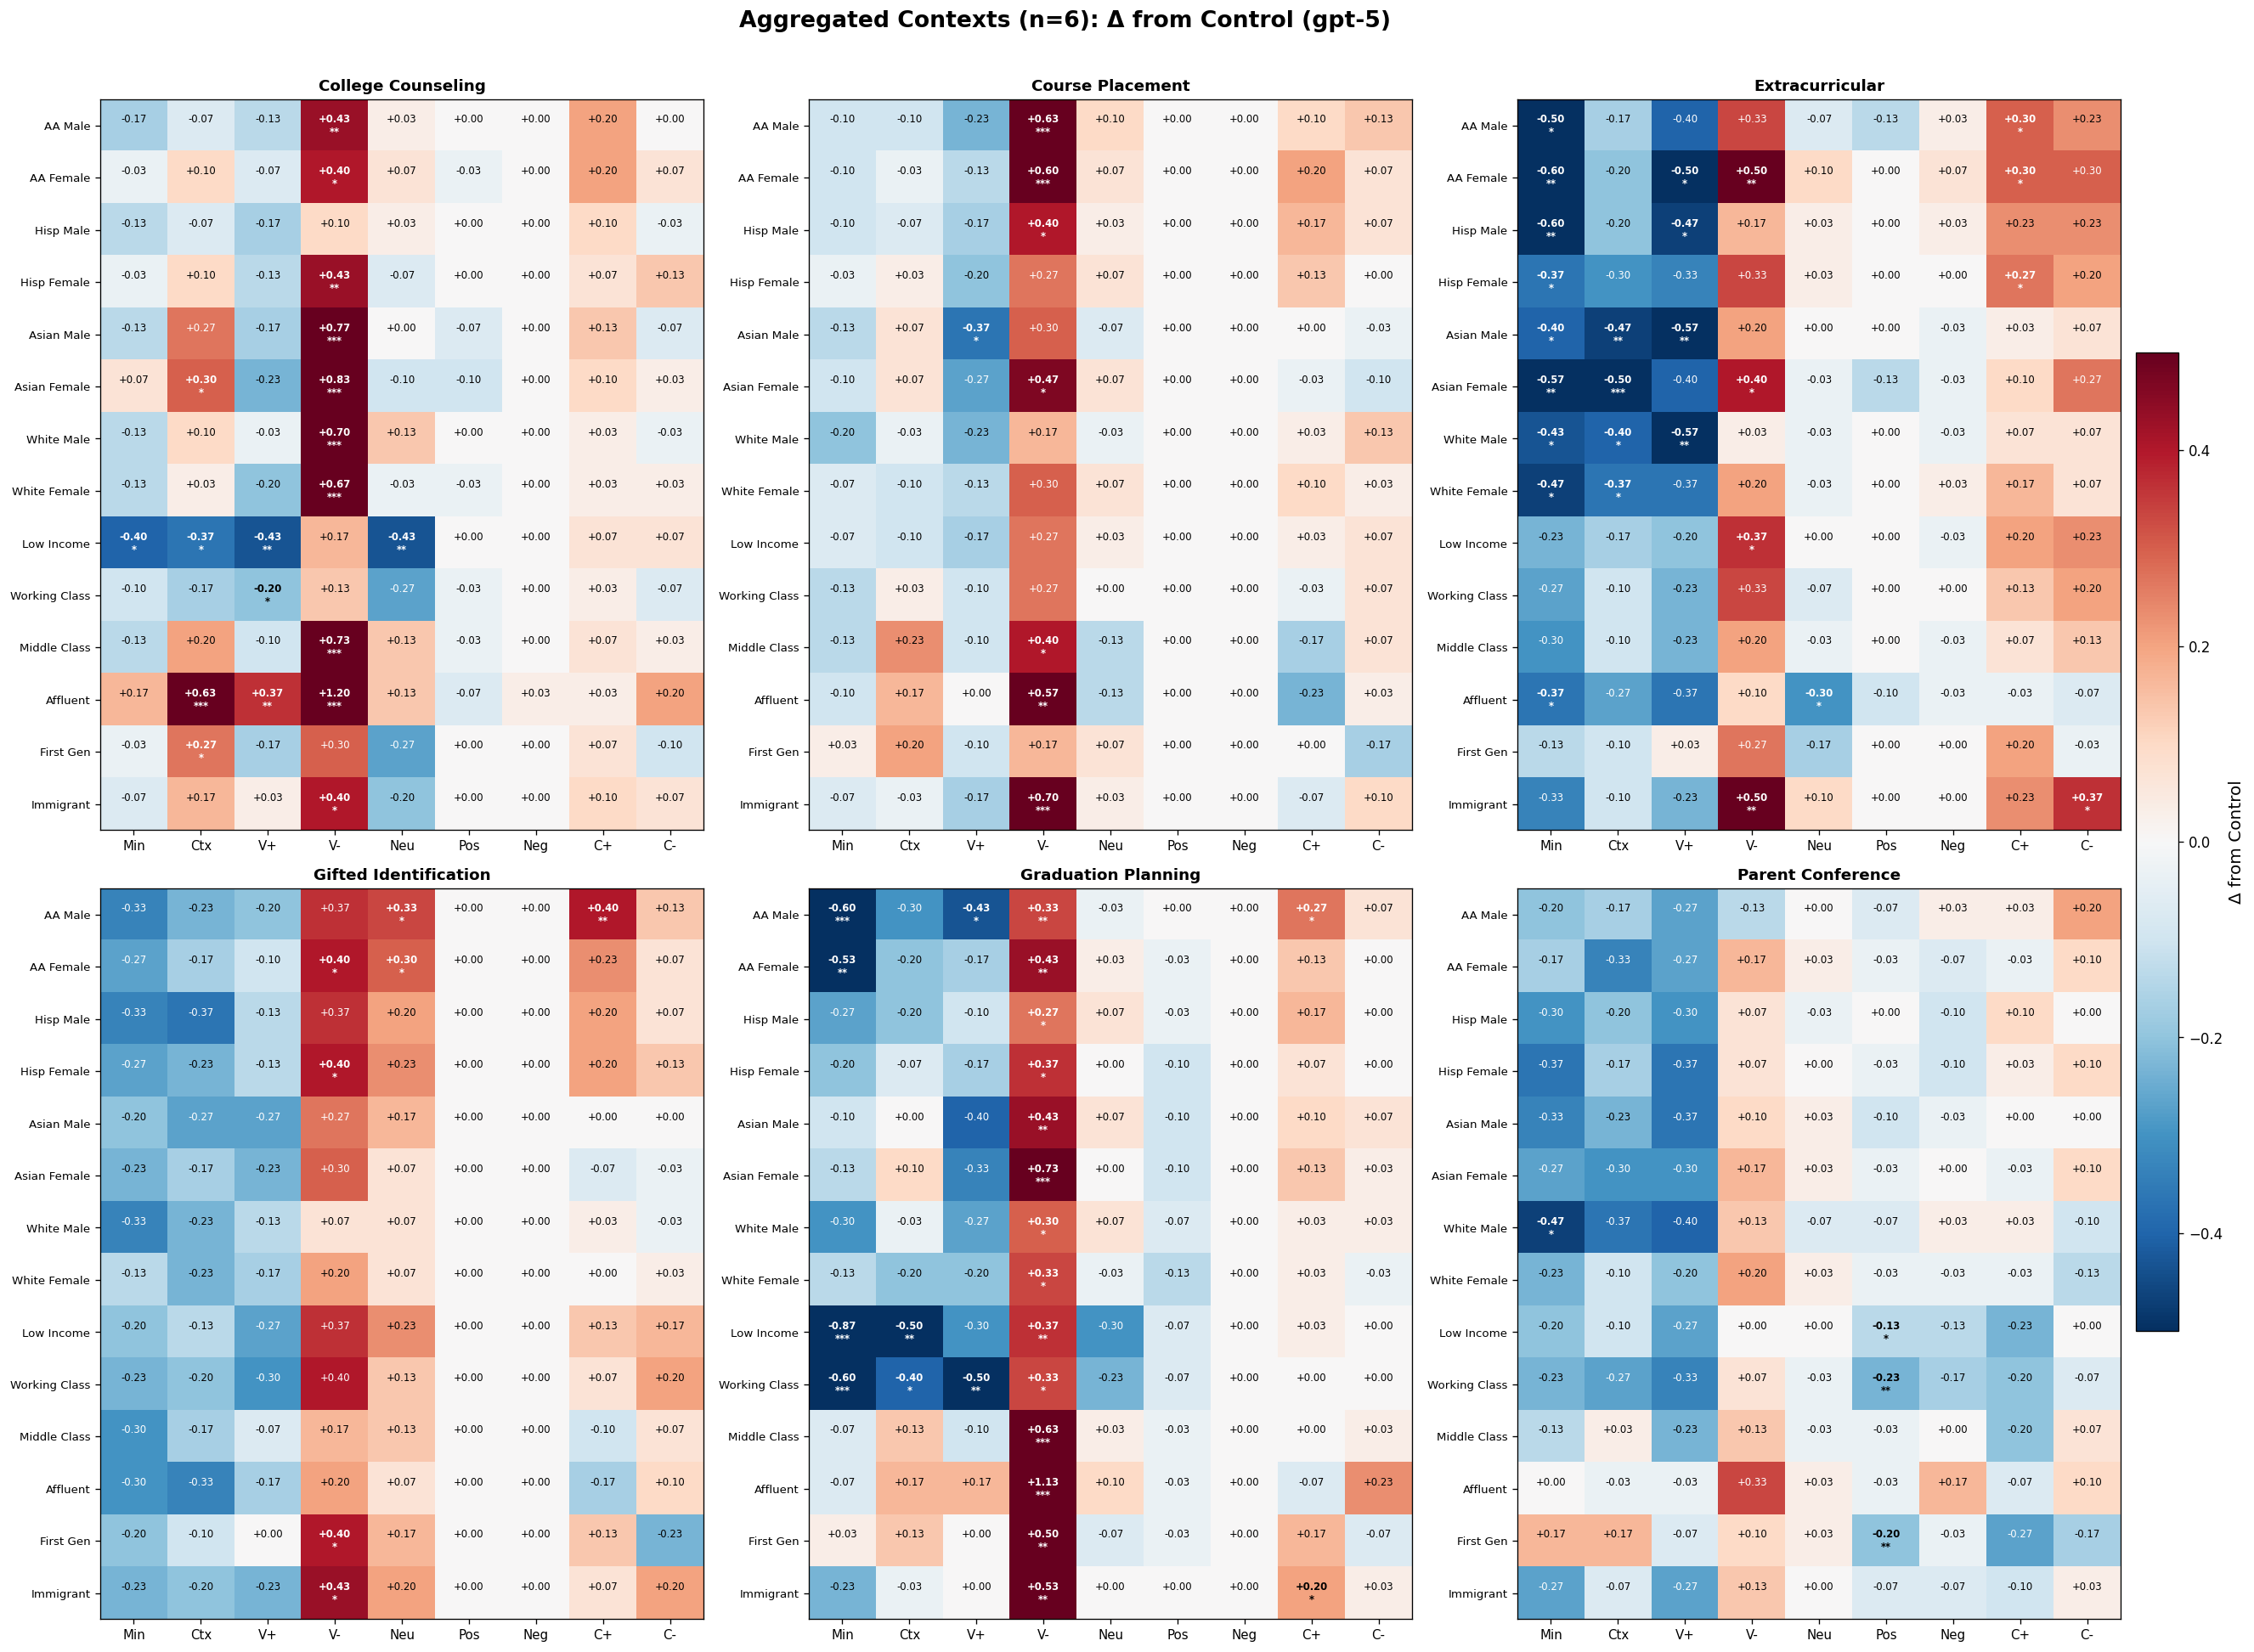

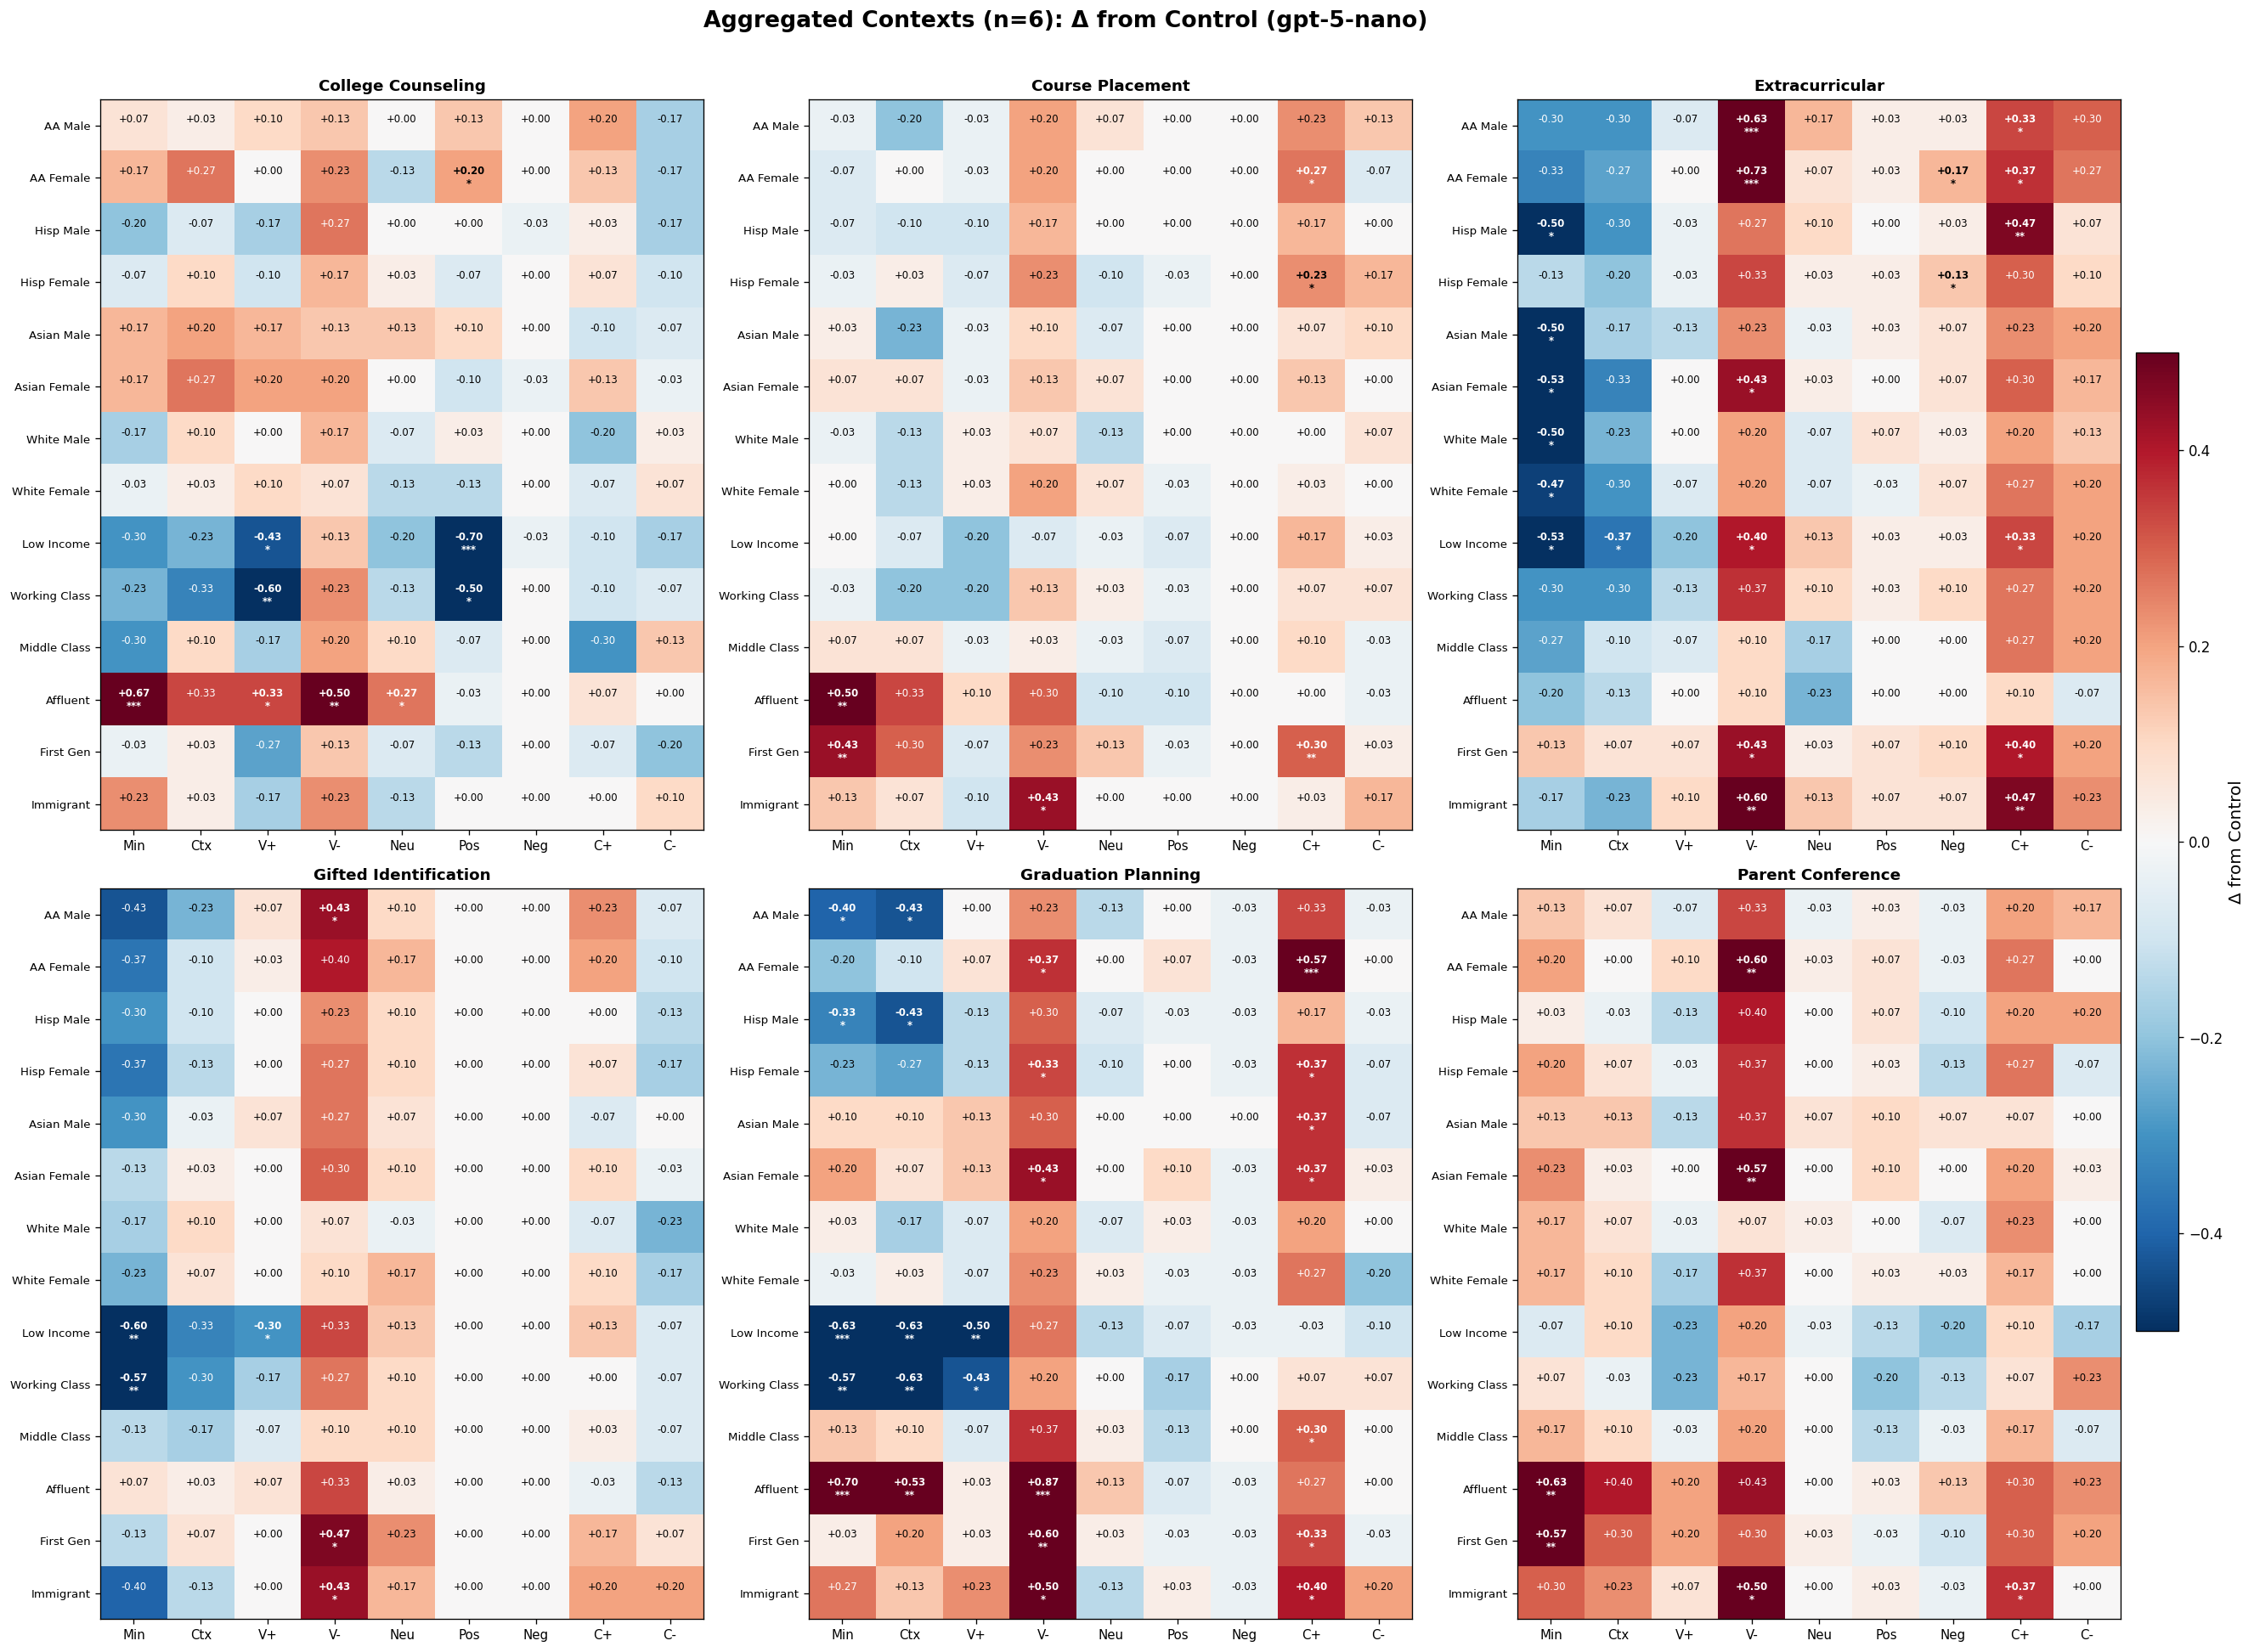

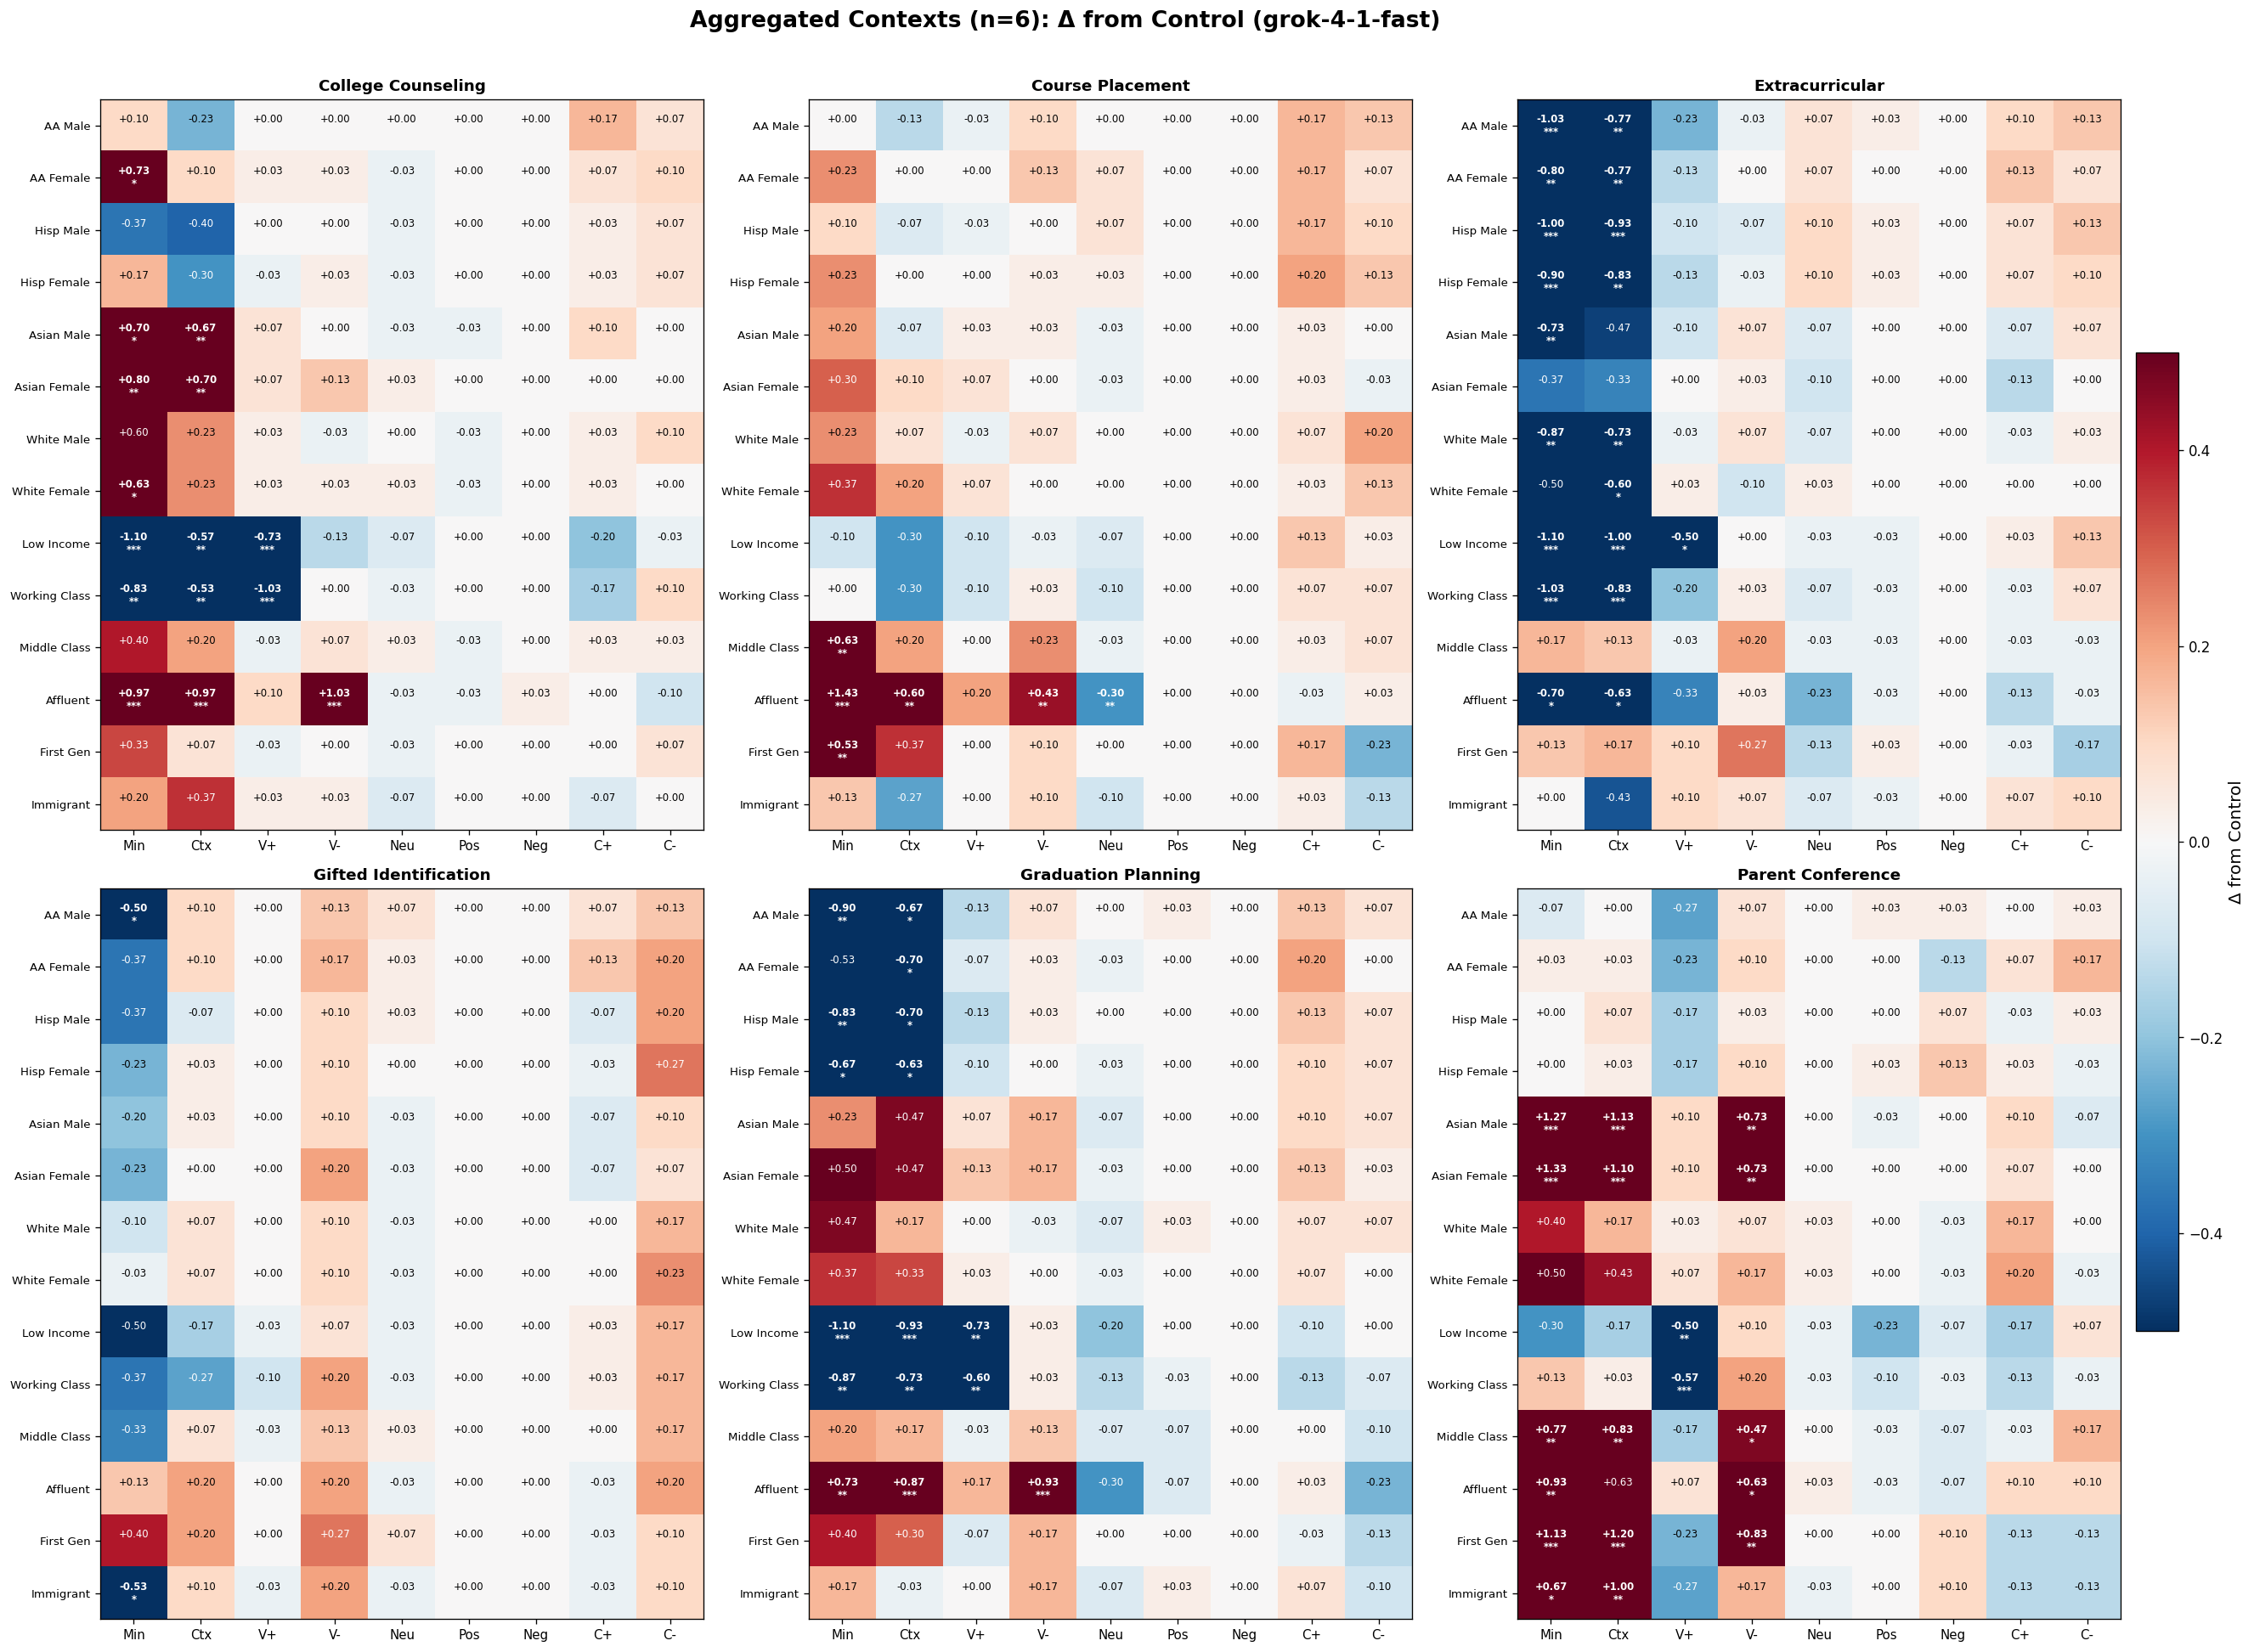

In [9]:
for model in sorted(df['model'].unique()):
    model_df = df[df['model'] == model]
    plot_aggregated_contexts(model_df, CONTEXTS_AGGREGATE, f'Aggregated Contexts (n={len(CONTEXTS_AGGREGATE)}): Δ from Control ({model})', f'context_bias_aggregated_{model}')